In [ ]:
import seaborn as sns
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import brainscore_vision
from brainscore_vision.benchmarks import BenchmarkBase

from brainscore_vision.benchmark_helpers.neural_common import average_repetition
from brainscore_vision.model_interface import BrainModel
from brainscore_vision import load_metric, load_dataset, load_model, load_ceiling #load_stimulus_set
from brainscore_vision.benchmark_helpers.neural_common import NeuralBenchmark #explained_variance
from brainscore_vision.model_helpers.brain_transformation import LayerScores, LayerMappedModel, TemporalAligned
from brainscore_vision.benchmark_helpers.screen import place_on_screen
from brainscore_vision.metrics.regression_correlation import CrossRegressedCorrelation

from brainscore_vision.metrics.regression_correlation import  linear_regression, pearsonr_correlation
from torchvision.models import AlexNet_Weights
#from vision.brainscore_vision.model_helpers.brain_transformation.neural import PreRunLayers
from pytorch_pretrained_vit import ViT

import functools
import torch
import torchvision.models
from torchvision.models import resnet18, alexnet,vit_b_16
from model_scores import Model, get_dataset,MyBenchmark

from brainscore_vision.model_helpers.activations.pytorch import PytorchWrapper
from brainscore_vision.model_helpers.activations.pytorch import load_preprocess_images
from brainscore_vision.model_helpers.brain_transformation.neural import PreRunLayers
from sklearn.decomposition import PCA
import brainscore_core
from brainscore_core.supported_data_standards.brainio.assemblies import NeuroidAssembly
from brainscore_core.supported_data_standards.brainio.transform import subset
from brainscore_core.supported_data_standards.brainio.assemblies import merge_data_arrays,walk_coords
import matplotlib.ticker as ticker
from tqdm import tqdm

In [2]:
neural_data = load_dataset("MajajHong2015.public")

neural_data = neural_data.transpose('presentation', 'neuroid', 'time_bin')
majaj_data = neural_data.squeeze('time_bin')
majaj_data = neural_data.mean(dim='time_bin', keep_attrs=True)
#benchmark_data['region'] = 'neuroid', ['IT'] * len(benchmark_data['neuroid'])
majaj_data.load()
majaj_data_avg = average_repetition(majaj_data)

In [3]:
freeman_data = load_dataset('FreemanZiemba2013.public')
freeman_data = freeman_data.transpose('presentation', 'neuroid', 'time_bin')
#benchmark_data = freeman_data#.sel(region='V2')
#time_window = (50, 200)
#freeman_data = freeman_data.sel(time_bin=[(t, t + 1) for t in range(*time_window)])
freeman_data = freeman_data.mean(dim='time_bin', keep_attrs=True)
#freeman_data = freeman_data.squeeze('time_bin')
#benchmark_data['region'] = 'neuroid', ['V4'] * len(benchmark_data['neuroid'])
freeman_data.load()
freeman_data_avg = average_repetition(freeman_data)

# PCA Reliability

In [16]:
def to_pcs(activations):
    X = activations - np.mean(activations,axis=0)
    U, S, Vt = np.linalg.svd(X,full_matrices=False)
    exp_var = (S**2) / (activations.shape[0] - 1)
    pcs = U*S
    return pcs,exp_var

In [185]:
def split(assembly):
    coord_values = np.unique(assembly['repetition'].values)
    dims = assembly['repetition'].dims
    return xr.DataArray(coord_values, coords={'repetition': coord_values}, dims=['repetition']).stack(**{dims[0]: ('repetition',)})


In [17]:
def reliability(dataset, splits=10, seed=125, pca=True,abs=False):
    split_scores = []
    rng = np.random.default_rng(seed=seed)
    coord_values = np.unique(dataset['repetition'].values)
    dims = dataset['repetition'].dims
    repetitions = xr.DataArray(coord_values, coords={'repetition': coord_values}, dims=['repetition']).stack(**{dims[0]: ('repetition',)})
    half = repetitions.shape[0]//2

    for i in range(splits):
        shuffle=rng.permutation(range(repetitions.shape[0]))
        half1 = repetitions.isel(presentation=shuffle[:half])
        half2 = repetitions.isel(presentation=shuffle[half:2*half])
        set1 = average_repetition(subset(dataset,half1,dims_must_match=False)).sortby('stimulus_id','neuroid_id')
        set2 = average_repetition(subset(dataset,half2,dims_must_match=False)).sortby('stimulus_id','neuroid_id')

        if pca:
            set1,_=to_pcs(set1)
            set2,_=to_pcs(set2)

        correlation = stats.pearsonr(set1,set2).correlation
        if pca and abs: correlation= np.abs(correlation)

        consistency = 2*correlation/(1+correlation)
        split_scores.append(consistency)

    return np.array(split_scores)


In [18]:
def plot_consistency(name,score,pcs):
    fig,ax= plt.subplots(figsize=(20,6))
    sns.barplot(score,ax=ax)
    label = 'PC' if pcs else 'Neuron'
    count = score.shape[1]
    ax.set(xlabel=label,xticks=range(0,count,5),title=f'{label} Consistency for {name} Neurons')
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    plt.savefig(f'neuron_consistency_plots/{name}-consistency-{label}.png',dpi=300,bbox_inches='tight')
    plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

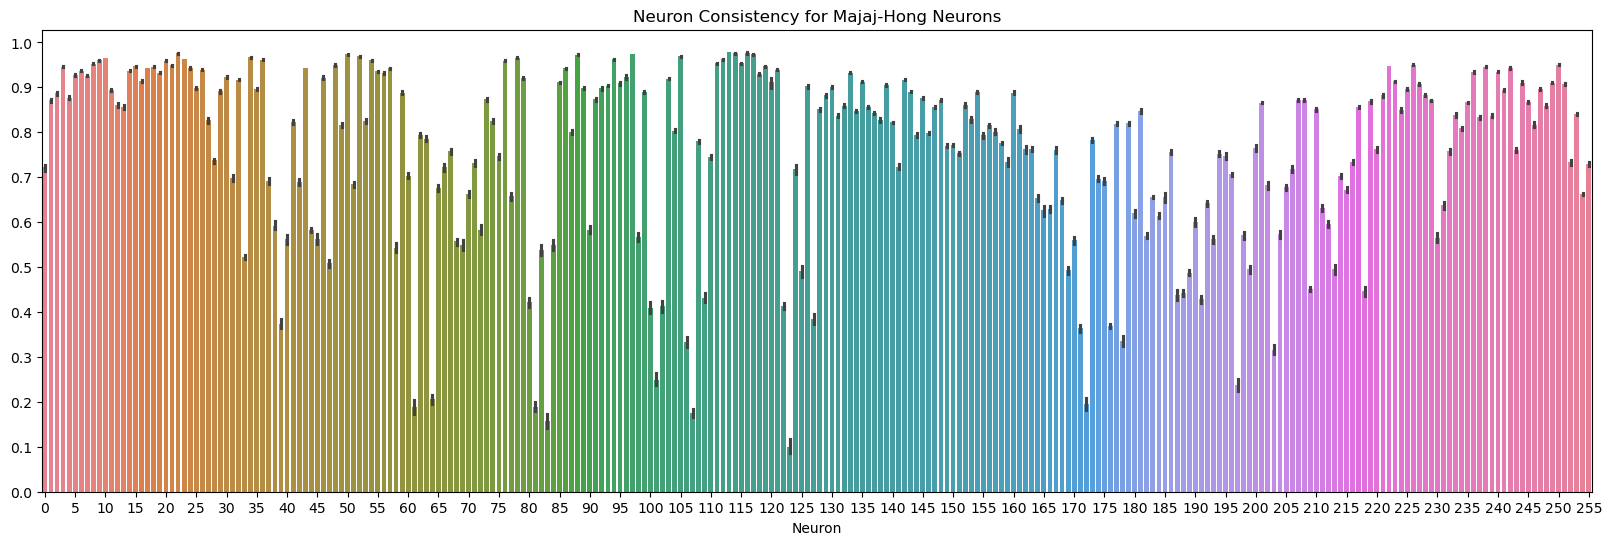

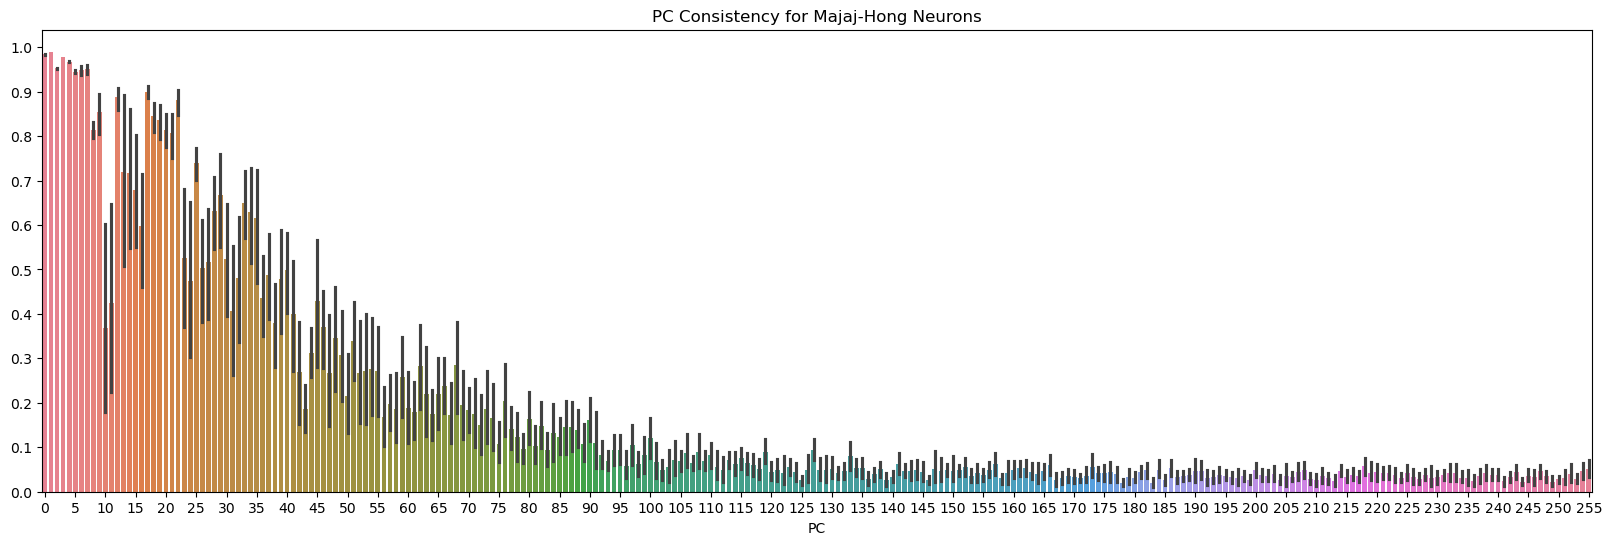

 17%|█▋        | 1/6 [00:53<04:29, 53.87s/it]/var/folders/0v/h9h6g0qx14l09jsvz9qfdhnh0000gn/T/ipykernel_6209/2631425517.py:20: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  correlation = stats.pearsonr(set1,set2).correlation
/var/folders/0v/h9h6g0qx14l09jsvz9qfdhnh0000gn/T/ipykernel_6209/2631425517.py:20: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  correlation = stats.pearsonr(set1,set2).correlation
/var/folders/0v/h9h6g0qx14l09jsvz9qfdhnh0000gn/T/ipykernel_6209/2631425517.py:20: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  correlation = stats.pearsonr(set1,set2).correlation
/var/folders/0v/h9h6g0qx14l09jsvz9qfdhnh0000gn/T/ipykernel_6209/2631425517.py:20: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurat

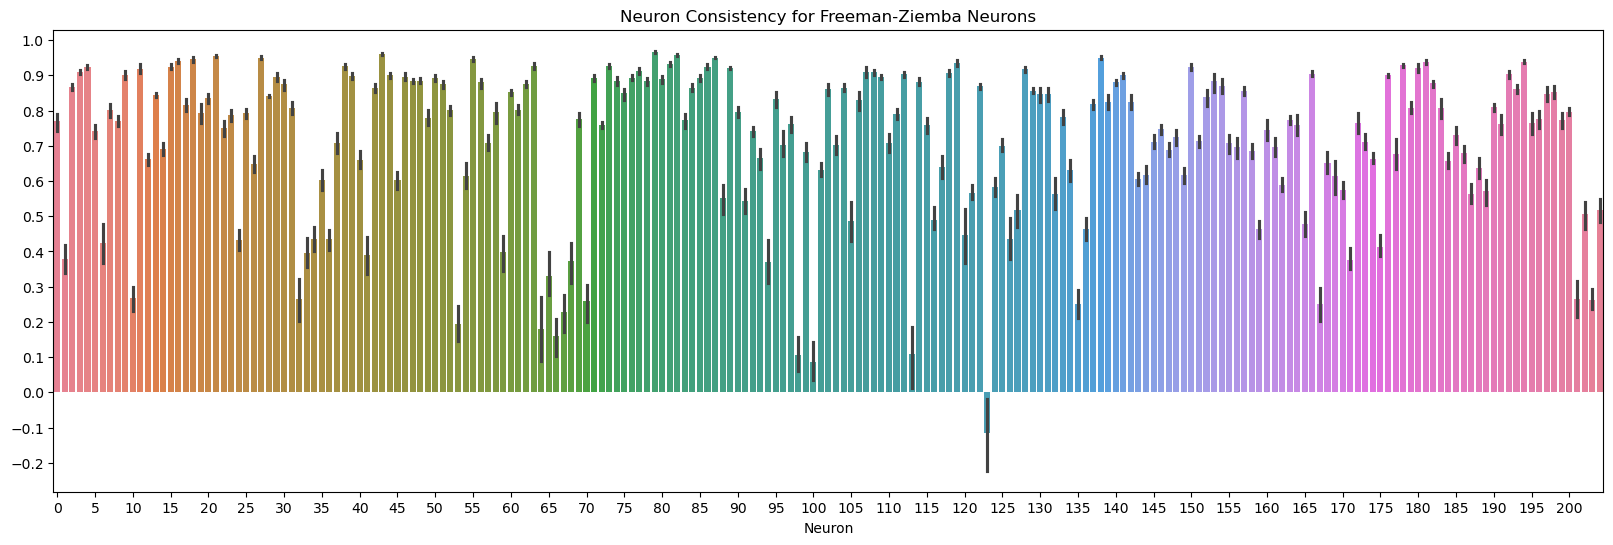

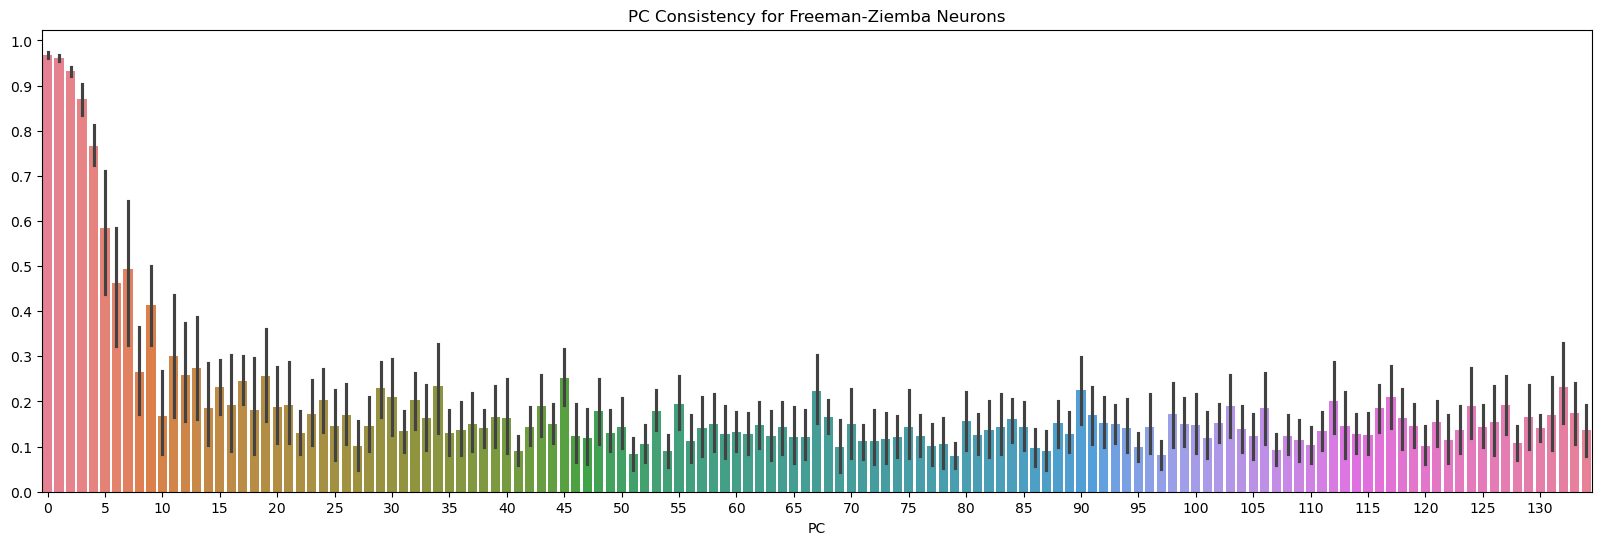

 33%|███▎      | 2/6 [01:01<01:45, 26.43s/it]

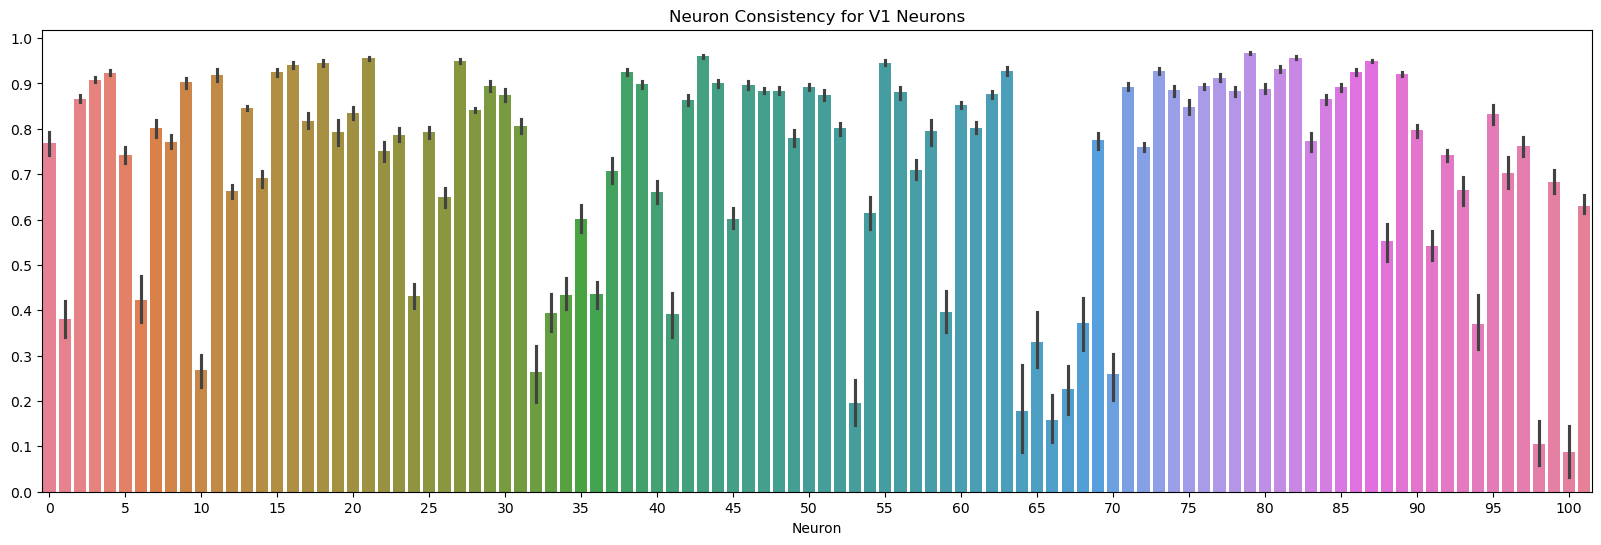

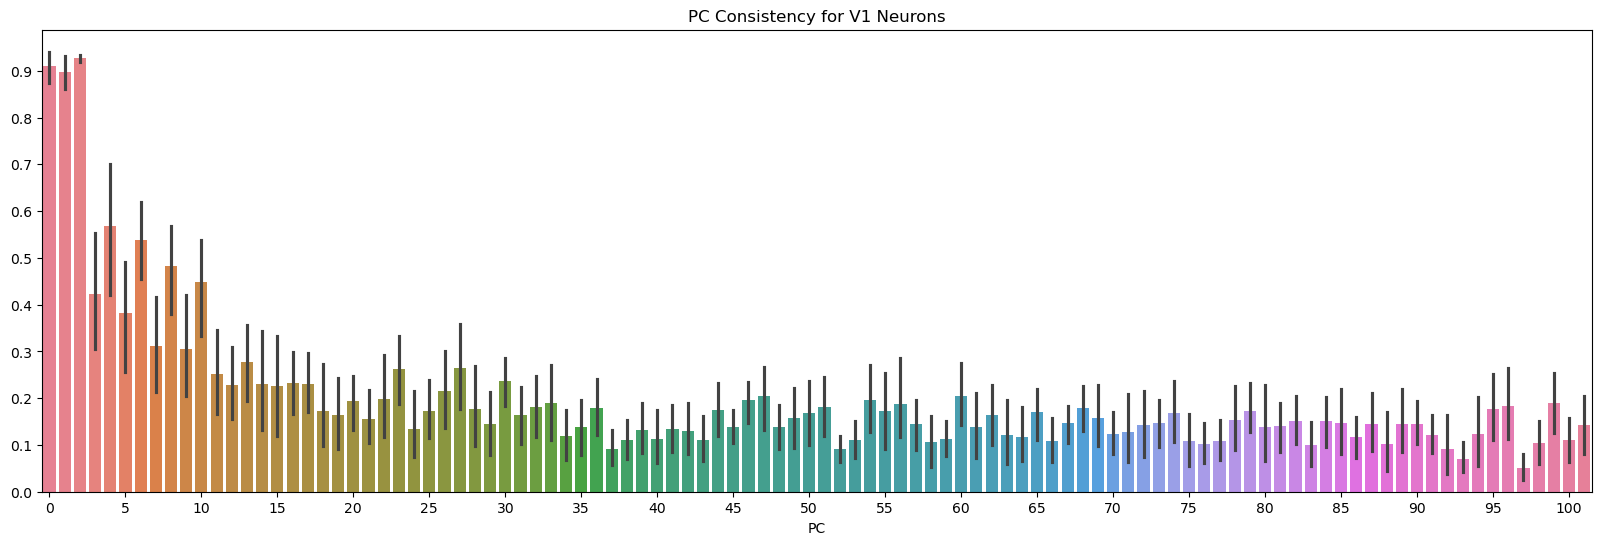

 50%|█████     | 3/6 [01:06<00:50, 16.84s/it]

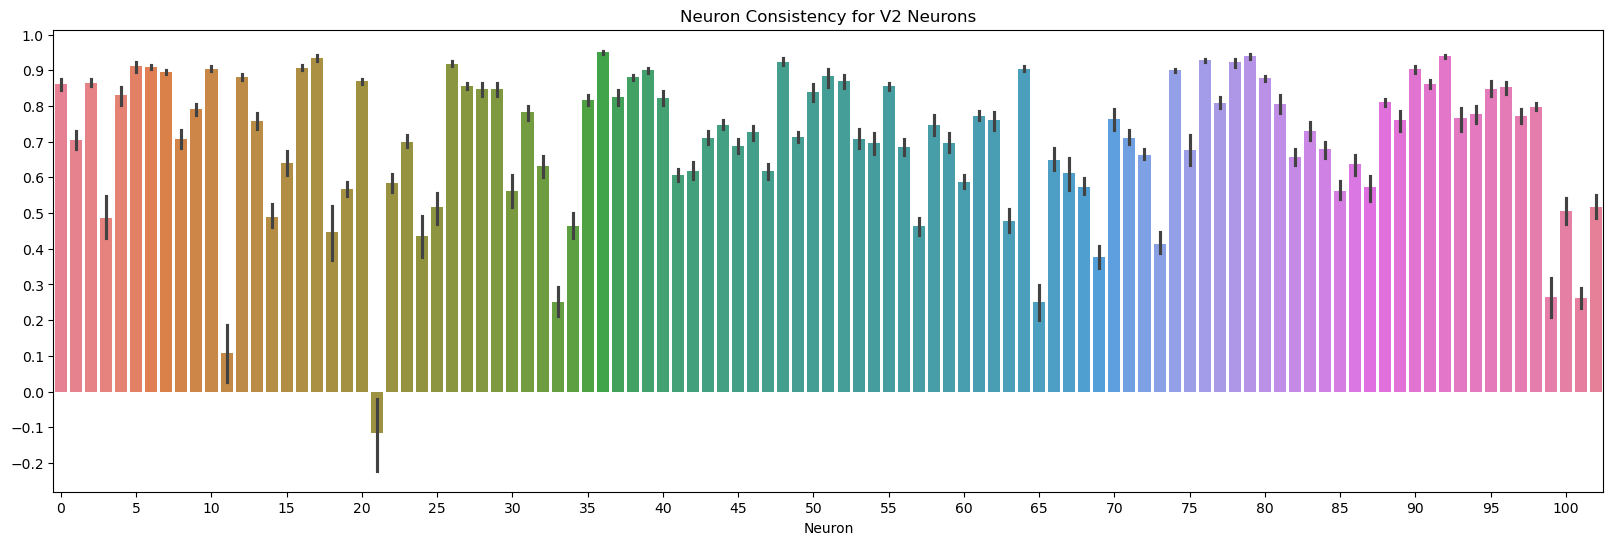

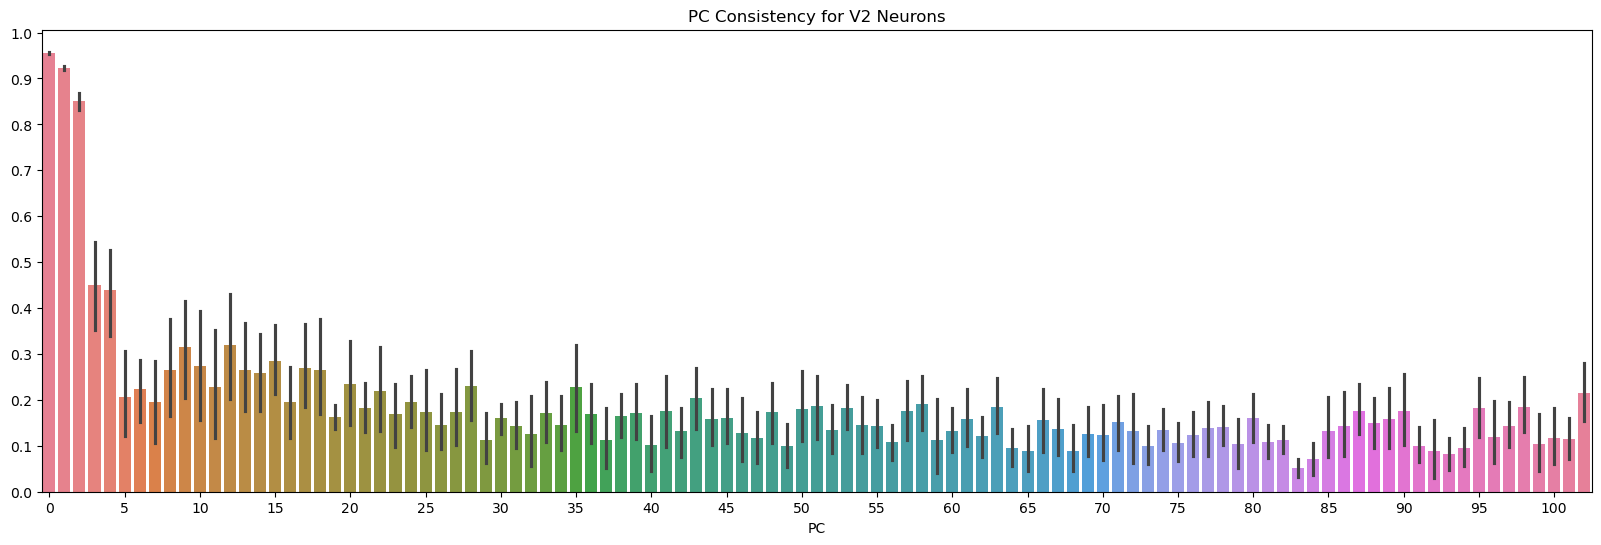

 67%|██████▋   | 4/6 [01:11<00:24, 12.21s/it]

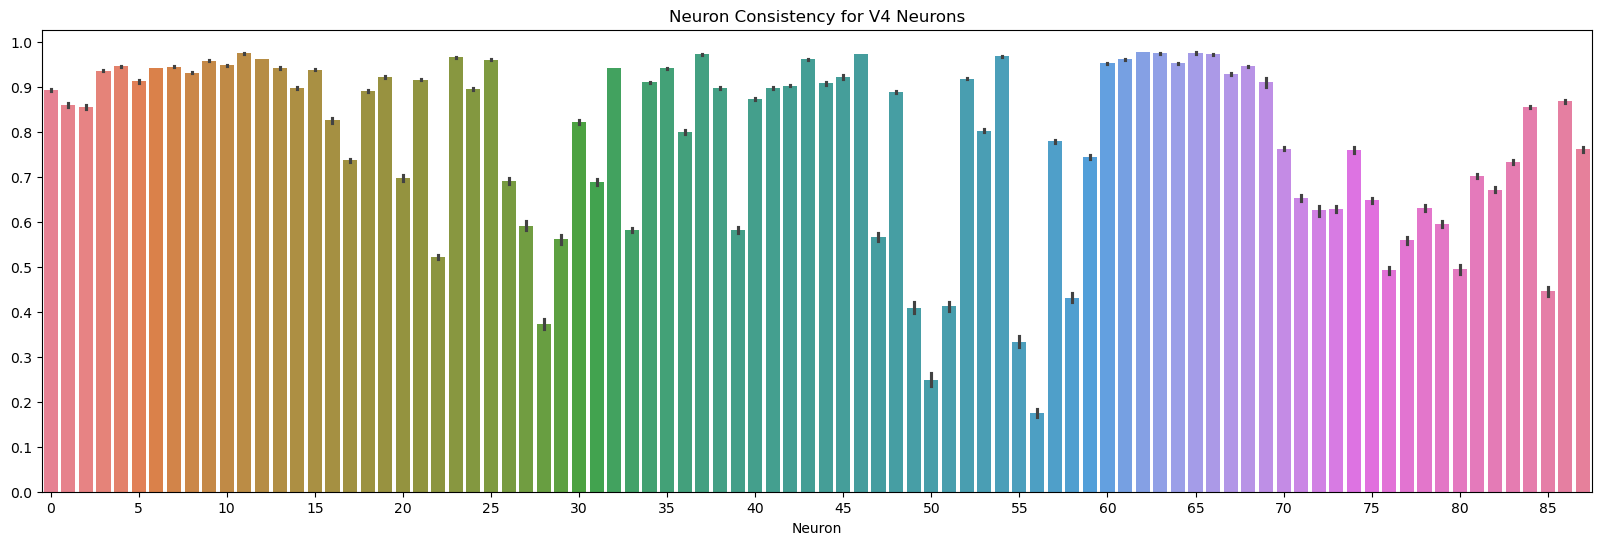

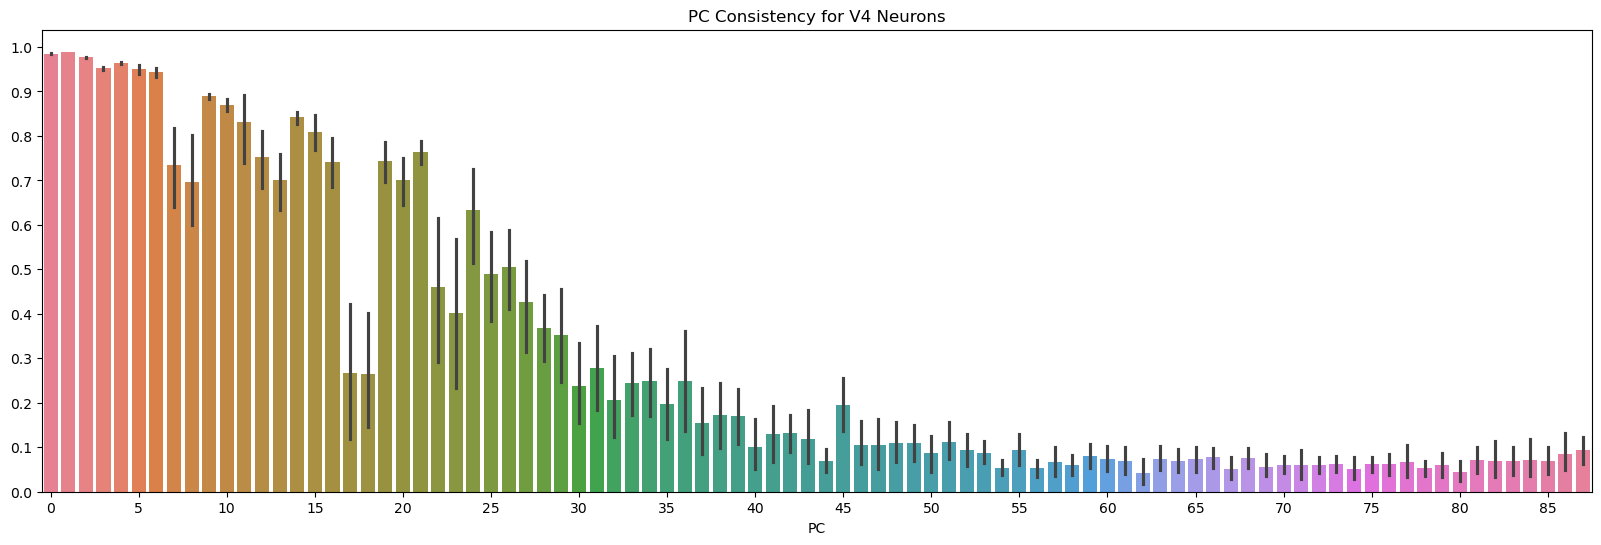

 83%|████████▎ | 5/6 [01:58<00:24, 24.61s/it]

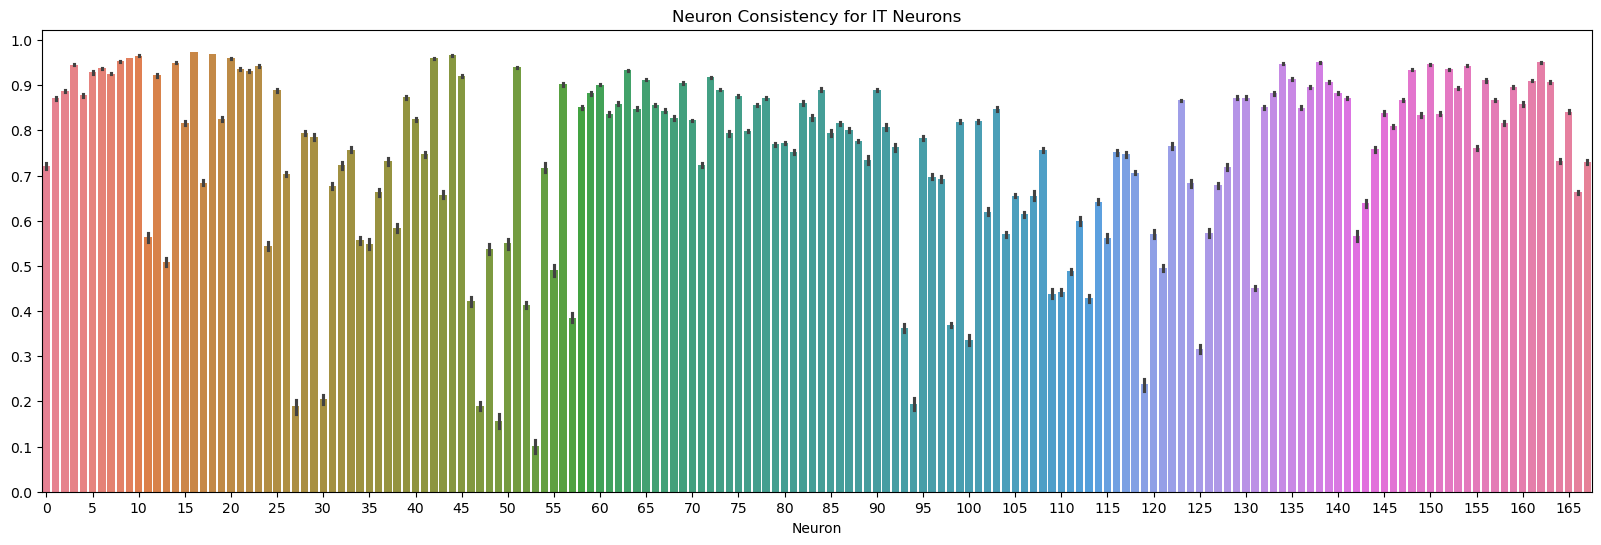

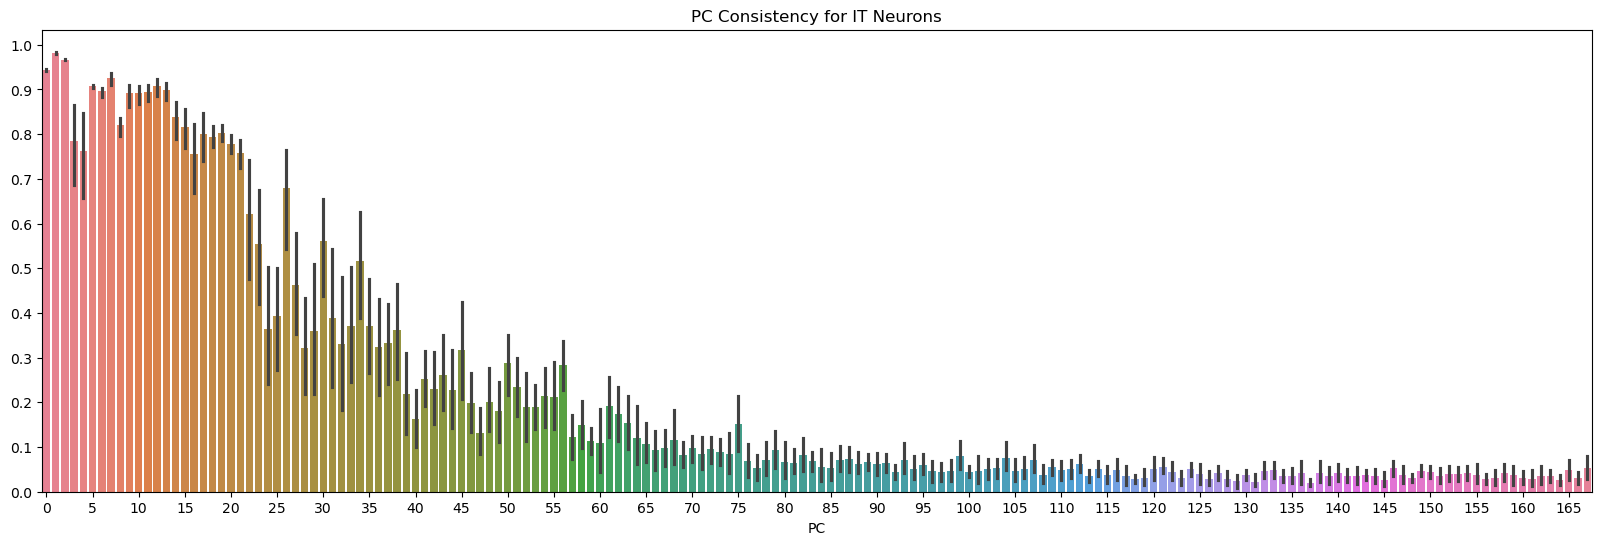

100%|██████████| 6/6 [02:49<00:00, 28.19s/it]


In [22]:
datasets = {
        'Majaj-Hong':majaj_data,
        'Freeman-Ziemba':freeman_data,
        'V1':freeman_data.sel(region='V1'),
        'V2':freeman_data.sel(region='V2'),
        'V4':majaj_data.sel(region='V4'),
        'IT':majaj_data.sel(region='IT'),
    }
for name,data in tqdm(datasets.items()):
    score = reliability(data,pca=False,splits=10)
    pc_score_abs = reliability(data,pca=True,splits=10,abs=True)
    plot_consistency(name,score,False)
    plot_consistency(name,pc_score_abs,True)

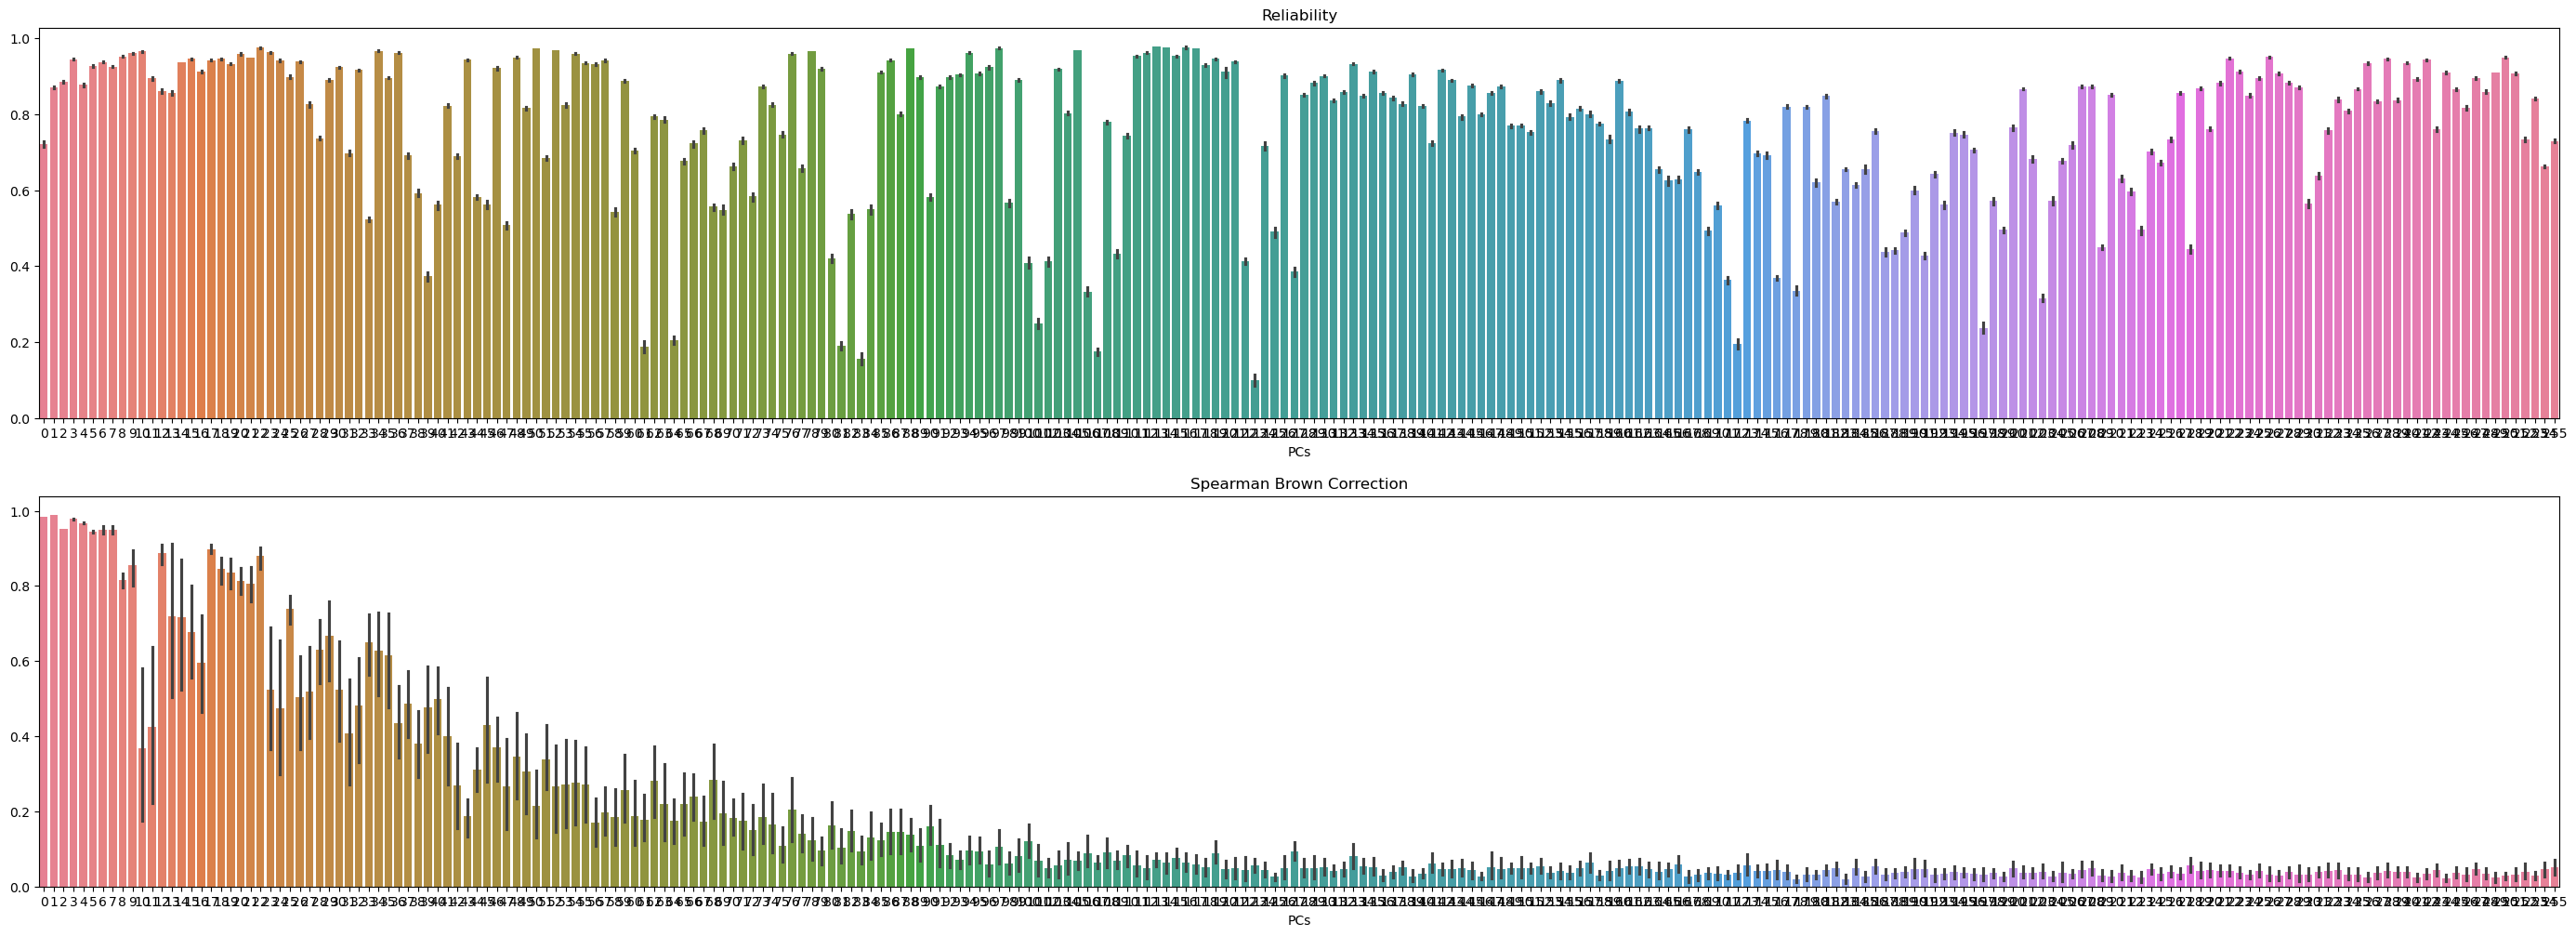

In [32]:
fig, ax = plt.subplots(nrows=2,figsize=(35, 12))
sns.barplot(score,ax=ax[0])
sns.barplot(pc_score_abs,ax=ax[1])
ax[0].set(xlabel='PCs',title='Reliability')
ax[1].set(xlabel='PCs',title='Spearman Brown Correction')
#plt.savefig('smb2.png',dpi=300,bbox_inches='tight')
plt.show()

In [292]:
np.where(pc_score.mean(axis=0)>0.5)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 27, 28, 31, 32, 40]),)

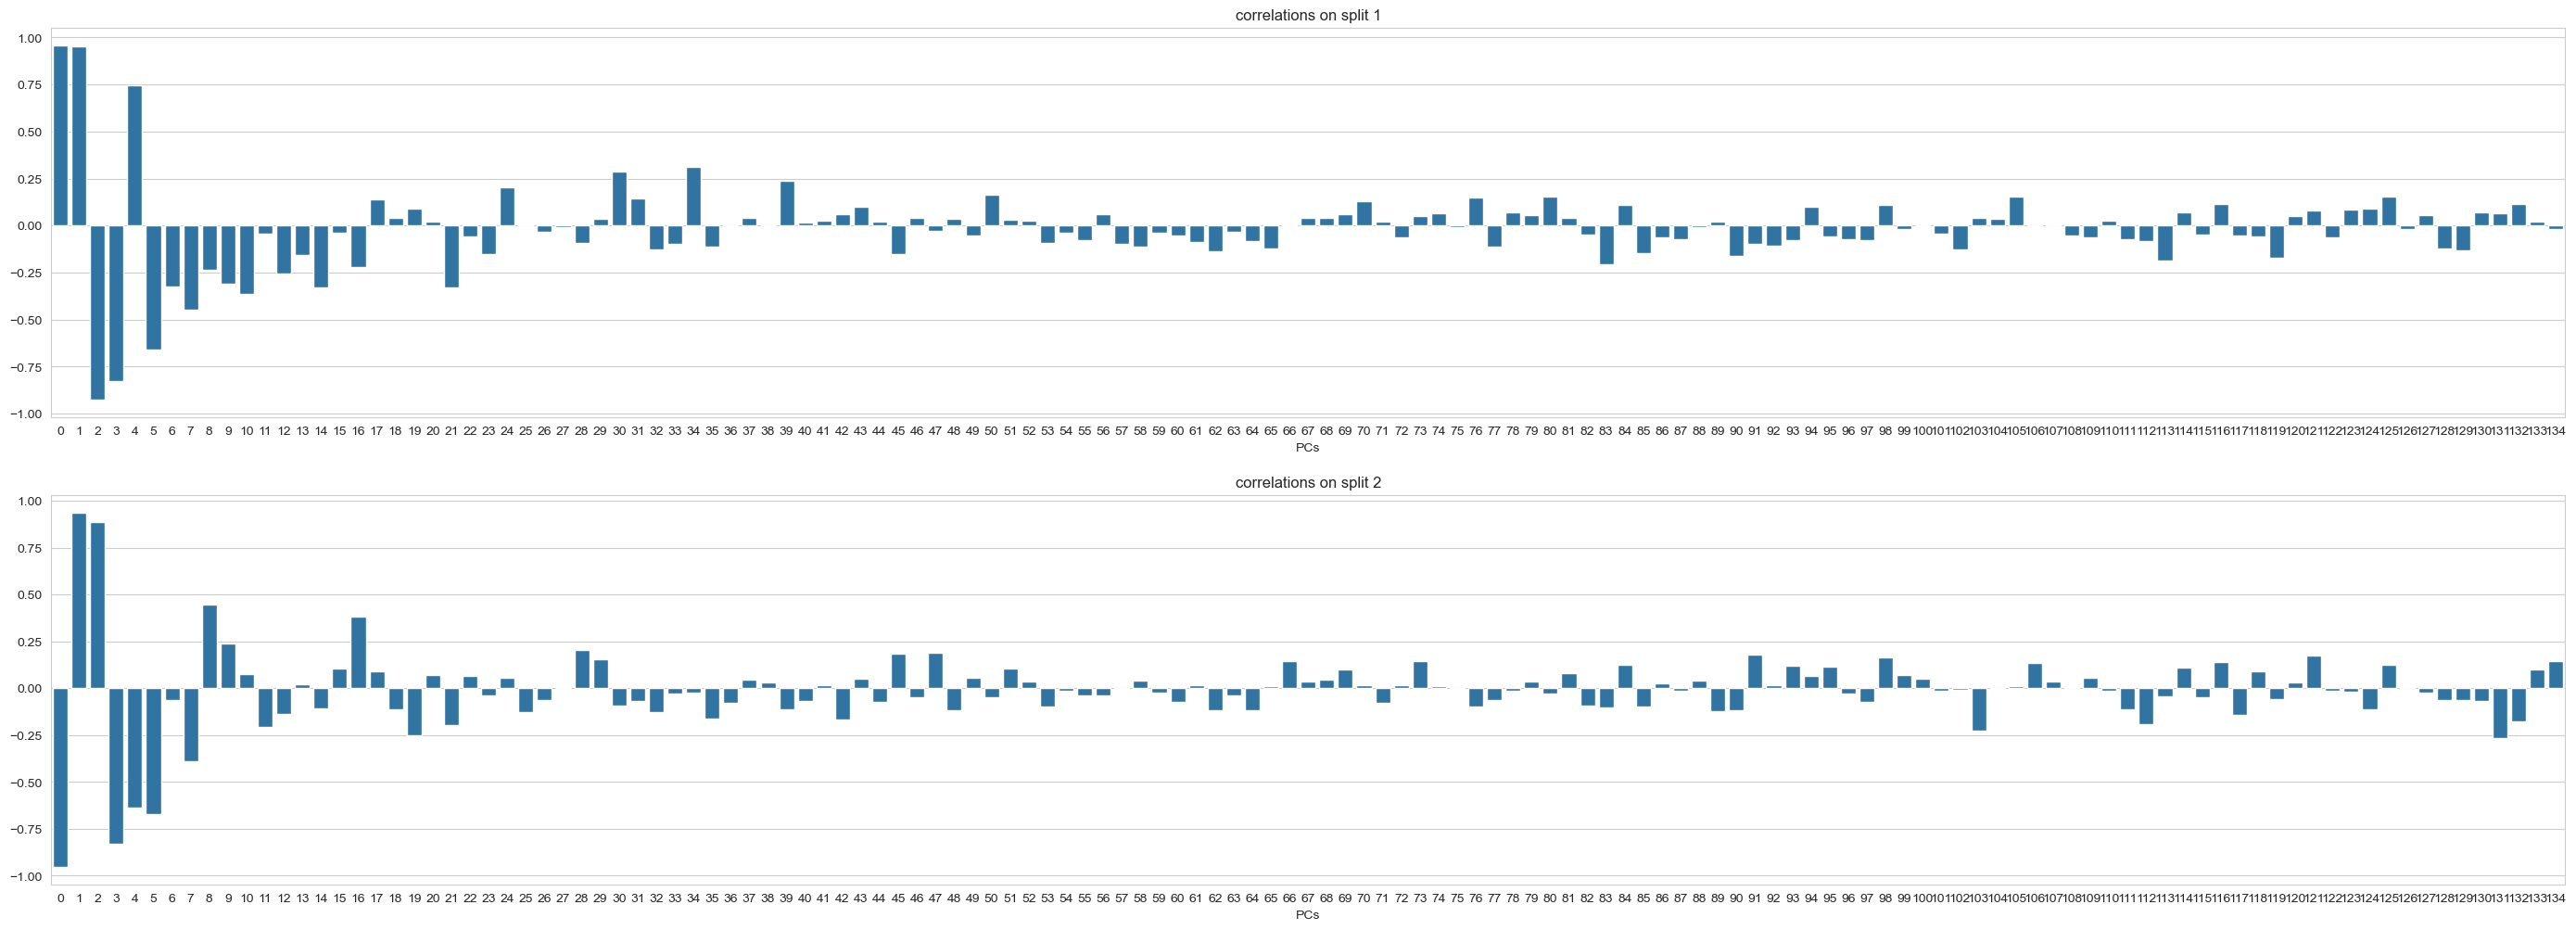

In [355]:
fig, ax = plt.subplots(nrows=2,figsize=(35, 12))
sns.barplot(correlation[0],ax=ax[0])
sns.barplot(correlation[1],ax=ax[1])
ax[0].set(xlabel='PCs',title='correlations on split 1')
ax[1].set(xlabel='PCs',title='correlations on split 2')
#ax.set(xlabel='PCs',ylabel='Reliability',xticklabels=[],title='MajajHong')
plt.savefig('pca_correlations1.png',dpi=300,bbox_inches='tight')
plt.show()

# Plotting

In [4]:
def get_layer_scores(scores_data):
    benchmarks = {}
    for x,y in scores_data.items():
        scored = xr.DataArray.to_pandas(y.raw.stack(z=('layer','split')))
        scored = scored.melt(ignore_index=False).reset_index()
        components = scored['neuroid_id'].unique()
        pc_map = dict(zip(components,range(len(components))))
        scored['pc'] = scored['neuroid_id'].map(pc_map)
        benchmarks[x] = scored
    return pd.concat(benchmarks).reset_index(drop=True)

In [5]:
regions = {
        'IT': get_dataset('MajajHong2015.public', 'IT'),
        'V4': get_dataset('MajajHong2015.public', 'V4'),
        'V2': get_dataset('FreemanZiemba2013.public', 'V2'),
        'V1': get_dataset('FreemanZiemba2013.public', 'V1')
    }


In [202]:
from brainscore_core.supported_data_standards.brainio.assemblies import NeuroidAssembly
def apply_pca(dataset):
    data = dataset.copy().sortby('neuroid_id','stimulus_id')
    data, eigens = xr.apply_ufunc(to_pcs,data,input_core_dims=[['presentation','neuroid']],output_core_dims=[['presentation','neuroid'],['neuroid']])
    data['pc'] = 'neuroid',  range(len(data['neuroid']))
    data['eigenvalues'] = eigens
    #data = data.set_index(neuroid=['pc','eigenvalues'],append=True)
    return NeuroidAssembly(data)

In [6]:
'''consistent_pcs = {
        'IT':range(25),
        'V4':range(25),
        'V2': [0,1,2,3,4,5,6],
        'V1': [0,1,2,3,4,5,6],
    }'''
consistent_pcs = {
        'IT': [0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,17, 18, 19, 20, 23, 24, 25, 26],
        'V4': [0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,17, 18, 21],
        'V2': [0, 1, 2],
        'V1': [0, 1, 2, 4, 6],
    }
alexnet_layers = ['features.5', 'features.7', 'features.9', 'features.12', 'classifier.2', 'classifier.5']
resnet_layers = ['layer1.0', 'layer2.0', 'layer3.0', 'layer4.0']
vit_layers = [f'encoder.layers.encoder_layer_{i}.mlp' for i in range(0,12,2)]


In [7]:
metric='pcr_cv3'
name = 'resnet18'
model = Model(identifier=name,model=resnet18,layers=resnet_layers,trained=True)

In [8]:
scores = {}
for region, dataset in regions.items():
    benchmark = MyBenchmark(identifier='benchmark', assembly=dataset, region=region,metric=metric,consistent=consistent_pcs[region])
    model_scorer = LayerScores(model_identifier=model.identifier,activations_model=model.activations,visual_degrees=8)
    scores[region] = model_scorer(benchmark,model.layers)

In [9]:
#data = pd.read_csv(f'{name}-scores-raw.csv')
data = get_layer_scores(scores)
data['layer'] = pd.Categorical(data['layer'],categories=model.layers)
data['region'] = pd.Categorical(data['region'],categories=['V1','V2','V4','IT'])
data.index.name = 'index'
data = data.sort_values(['layer','region','index'])
map = {'V1':'Freeman','V2':'Freeman','V4':'Majaj','IT':'Majaj'}
data['dataset'] = [map[i] for i in data['region']]

In [294]:
pc_score_abs = reliability(majaj_data,pca=True,splits=10,abs=True)

In [310]:
d1 =data.loc[(data['region']=='IT')&(data['layer']=='layer1.0'),['value','split','pc']].pivot(columns='pc',index='split').mean()
d2 = pc_score_abs.mean(axis=0)

In [319]:
d3=d2[:160]-d1[:160]

<Axes: xlabel='pc'>

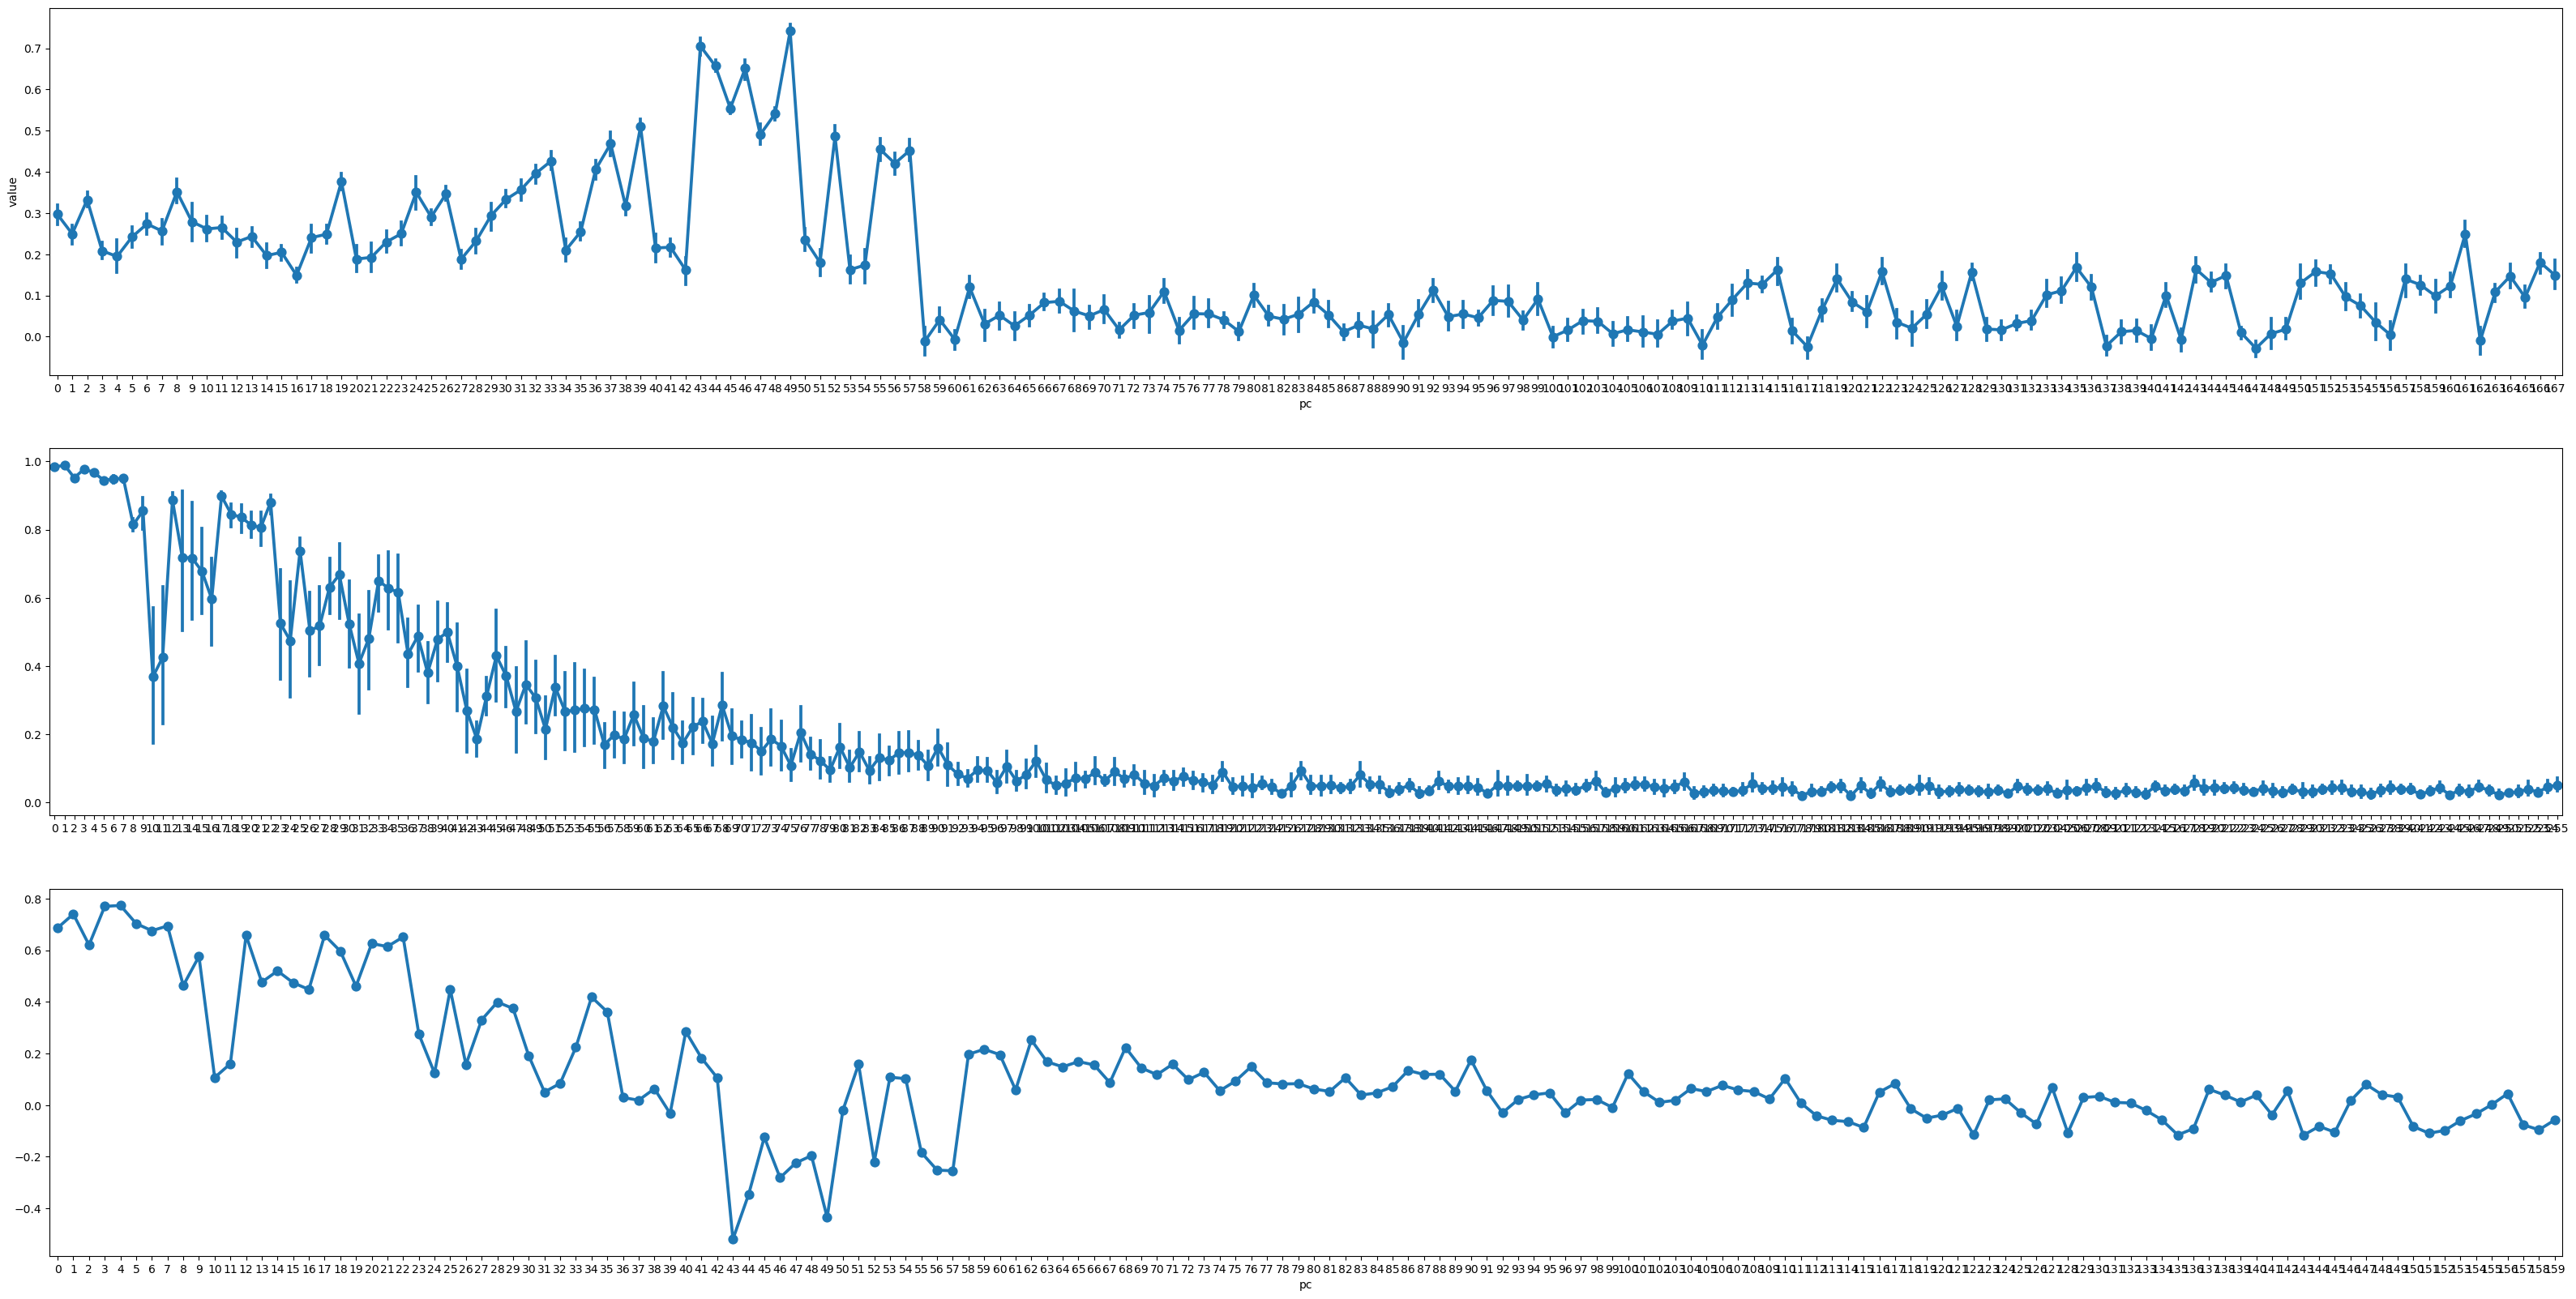

In [320]:
fig, ax = plt.subplots(nrows=3,figsize=(40,20))
sns.pointplot(data[(data['region']=='IT')&(data['layer']=='layer1.0')],x='pc',y='value',ax=ax[0])
sns.pointplot(pc_score_abs,ax=ax[1])
sns.pointplot(d3['value'],ax=ax[2])

In [ ]:
#plt.tight_layout()

sns.set_style('whitegrid')
ax=sns.catplot(data,col='region',x='layer',y='value',kind='bar',linestyle='none',hue='pc',palette='hls',aspect=2)
#ax.set(xlabel='neuron',xticks=[])
ax.figure.suptitle(f'{name} neuron scores with {metric}',y=1.05)
#plt.savefig(f'{name}-{metric}-neurons',dpi=300,bbox_inches='tight')
plt.show()

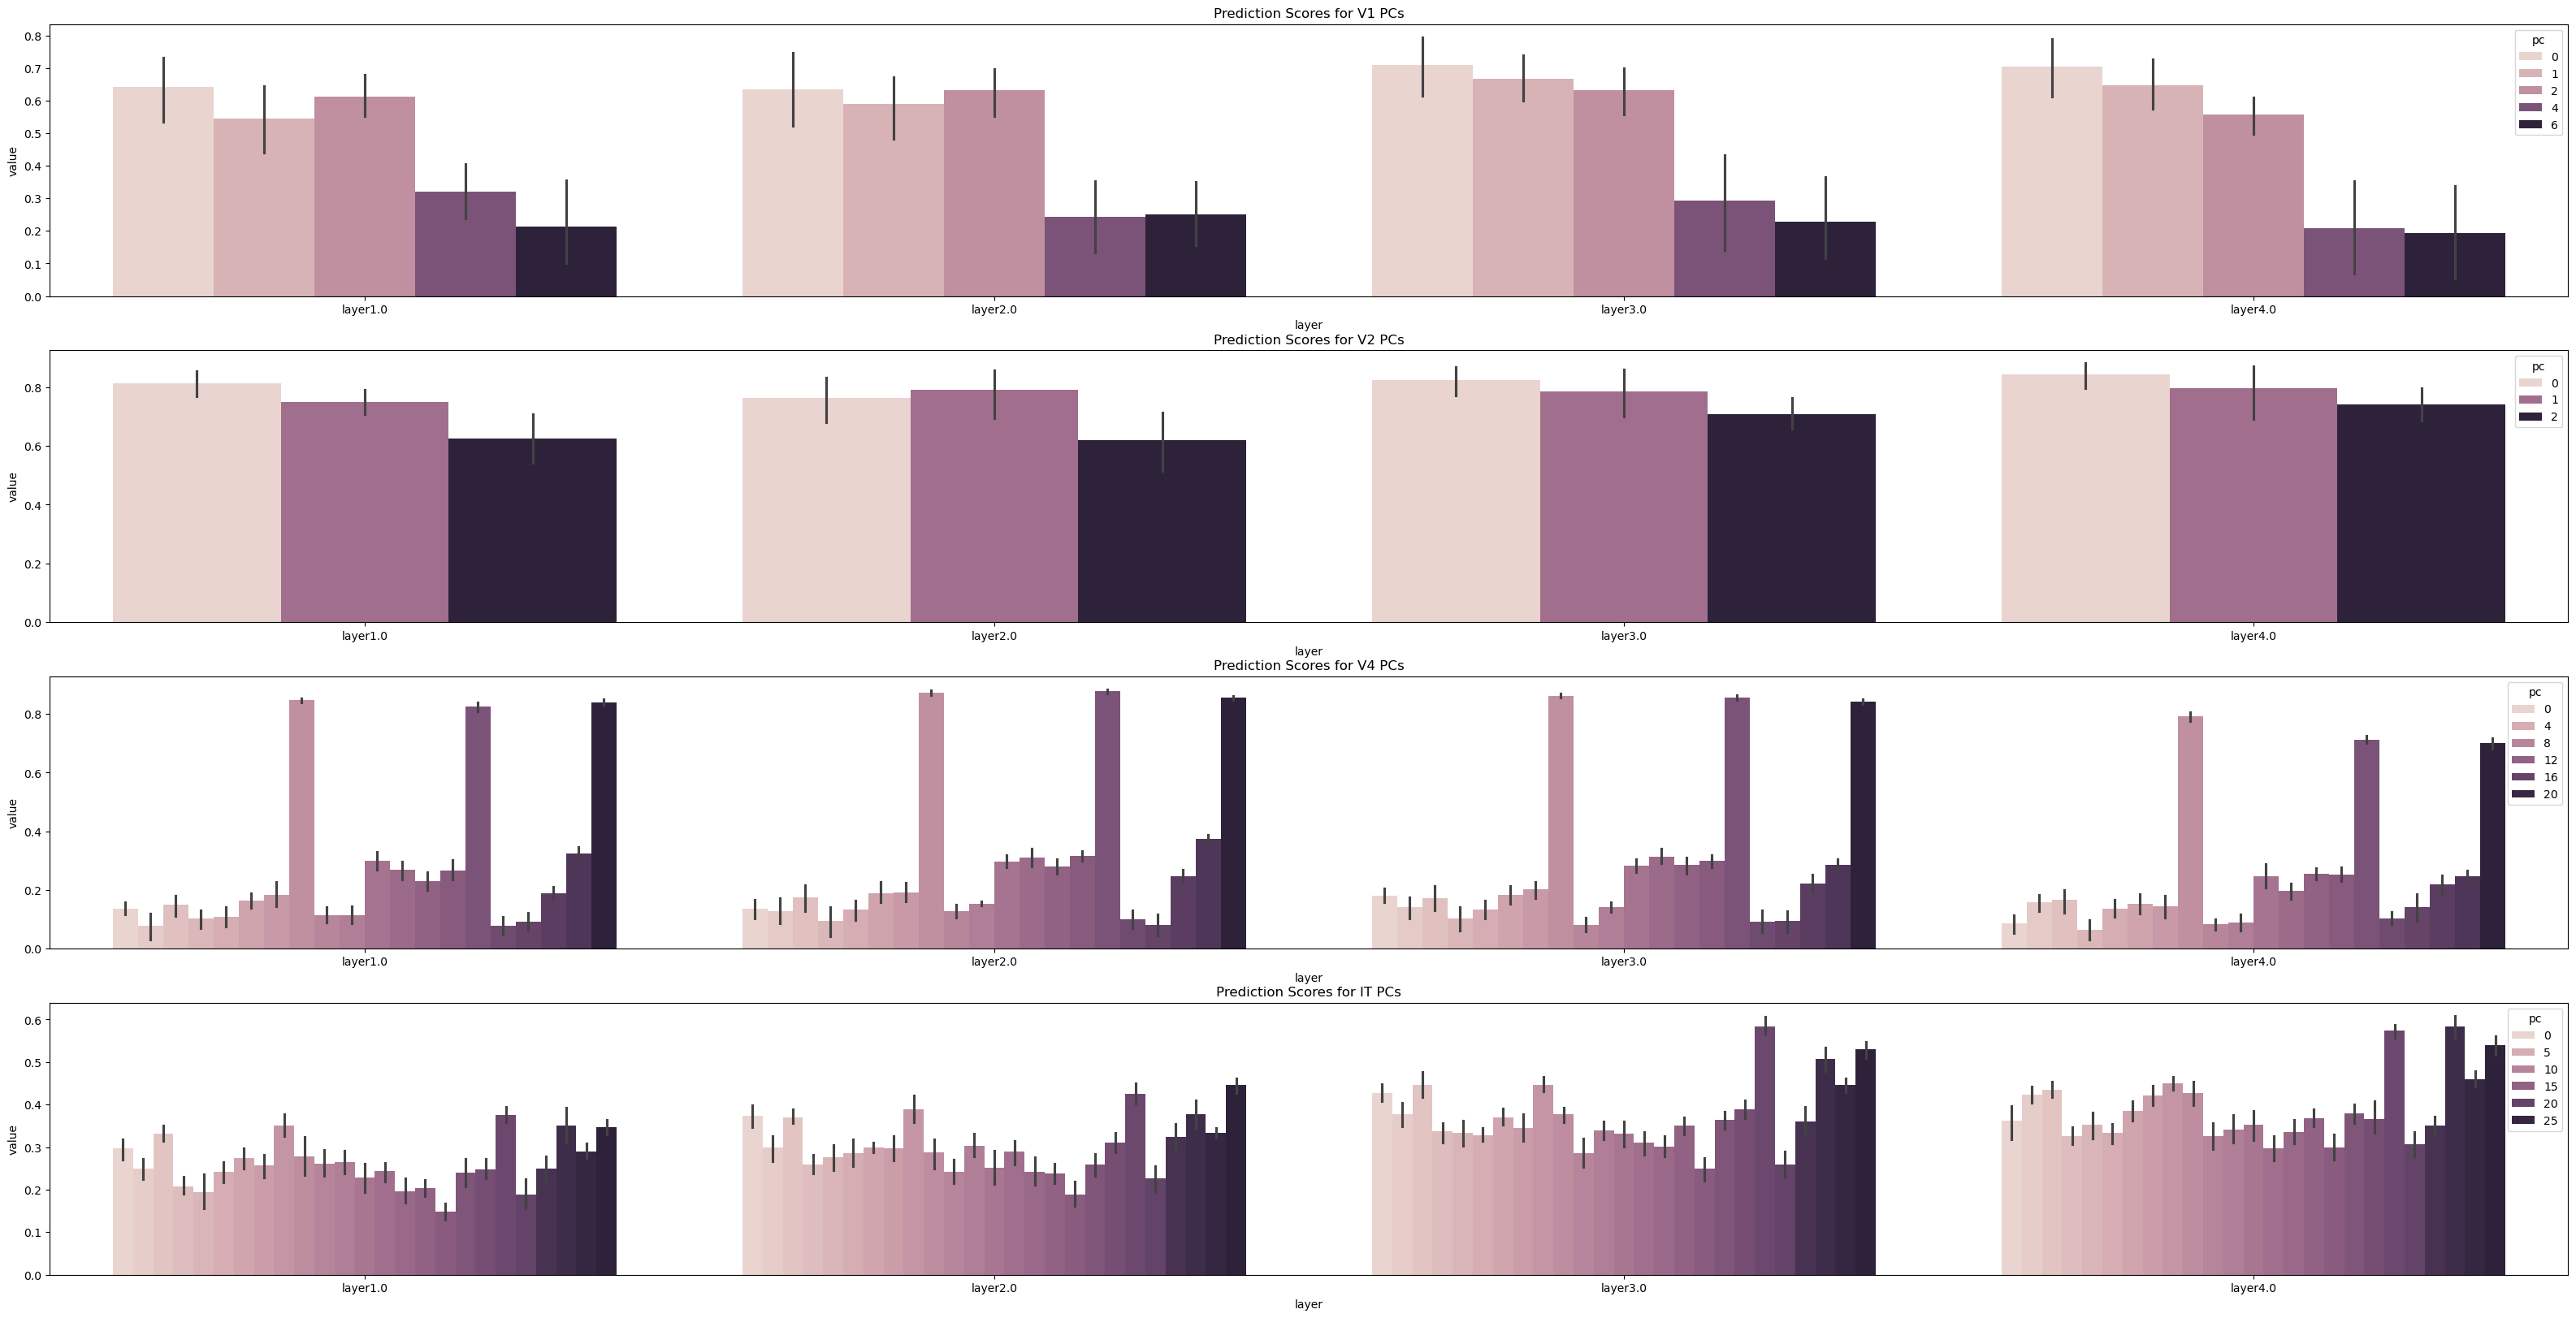

In [13]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(40,20))
sns.barplot(data[(data['region']=='V1')&(data['pc'].isin(consistent_pcs['V1']))],x='layer',y='value',hue='pc',ax=ax[0])
sns.barplot(data[(data['region']=='V2')&(data['pc'].isin(consistent_pcs['V2']))],x='layer',y='value',hue='pc',ax=ax[1])
sns.barplot(data[(data['region']=='V4')&(data['pc'].isin(consistent_pcs['V4']))],x='layer',y='value',hue='pc',ax=ax[2])
sns.barplot(data[(data['region']=='IT')&(data['pc'].isin(consistent_pcs['IT']))],x='layer',y='value',hue='pc',ax=ax[3])
for i,r in enumerate(['V1','V2','V4','IT']):
    ax[i].set(title=f'Prediction Scores for {r} PCs')
#plt.savefig(f'{name}-{metric}-neurons',dpi=300,bbox_inches='tight')

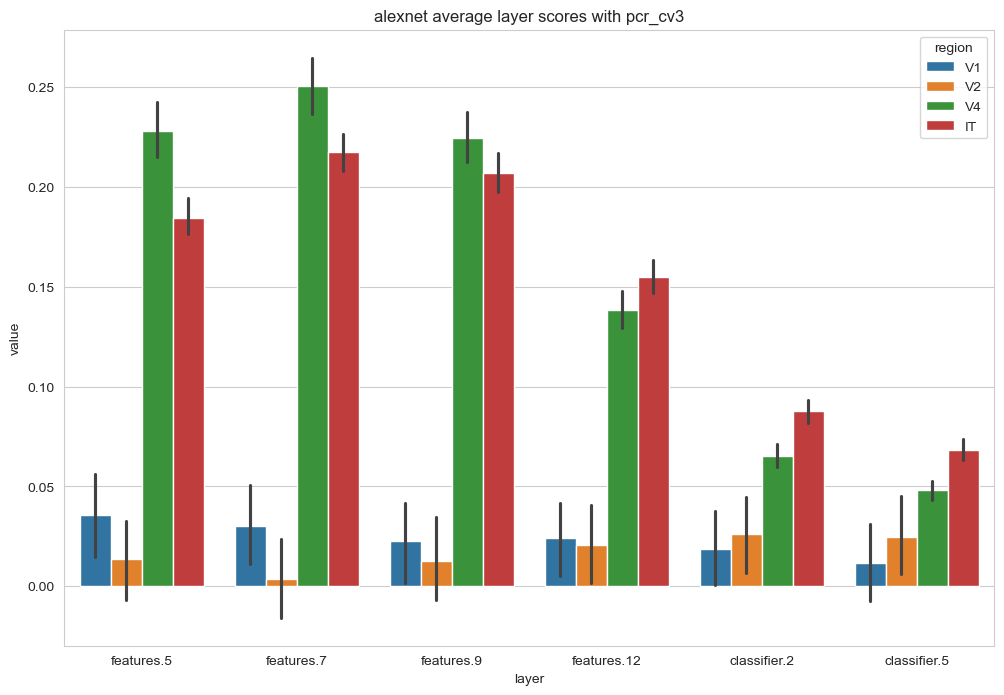

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))
#layers = [f'encoder_layer_{i}' for i in range(0,12,2)]
sns.barplot(data,x='layer',y='value',hue='region',ax=ax)
ax.set(title=f'{name} average layer scores with {metric}')
#ax.set_xticklabels(layers)
#ax.tick_params(axis='x', labelrotation=45)
plt.savefig(f'{name}-{metric}-mean',dpi=300,bbox_inches='tight')
plt.show()

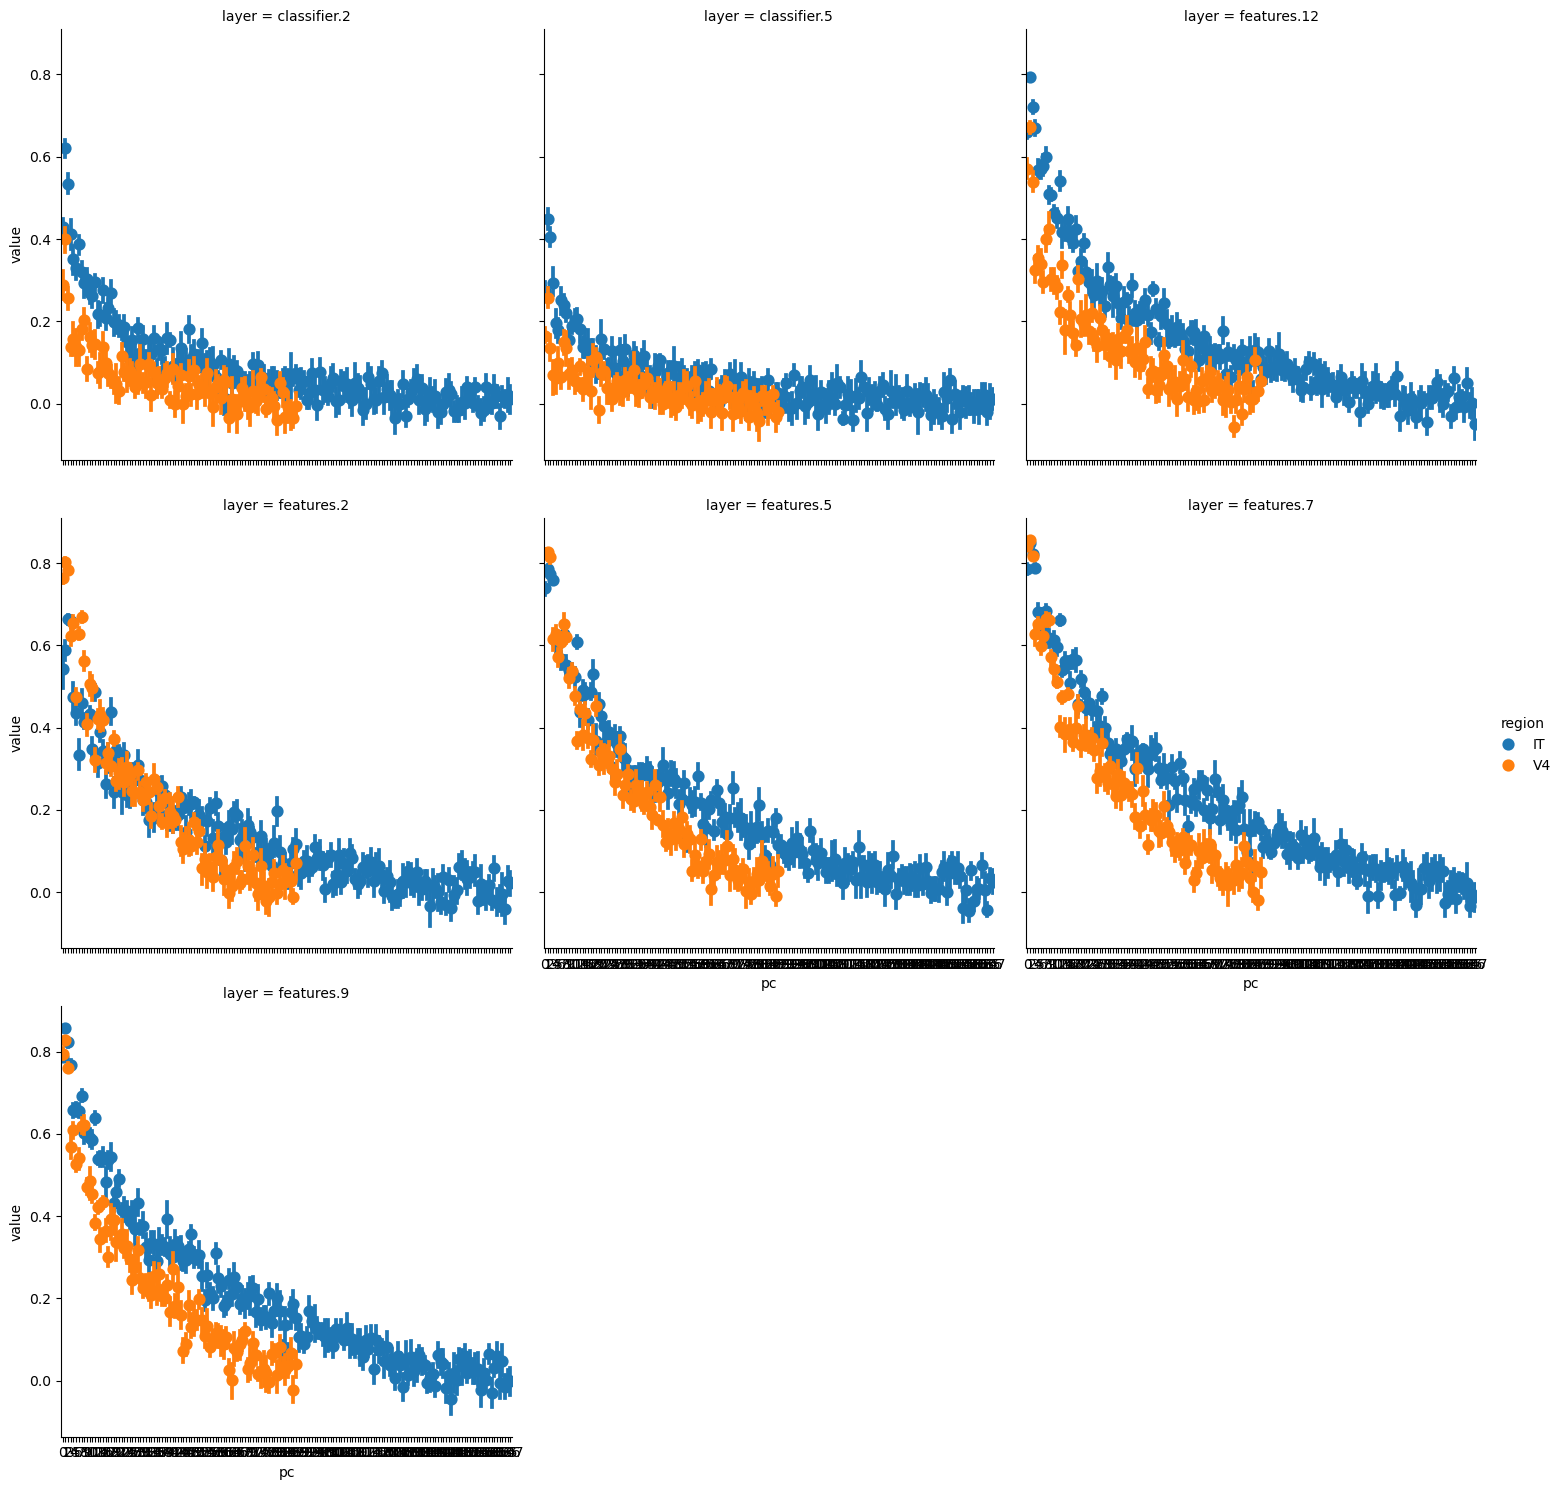

In [943]:
sns.catplot(data,col='layer',col_wrap=3,x='pc',y='value',kind='point',linestyle='none',hue='region')

# Model Evaluation Experiments

In [42]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [43]:
def get_model(model,identifier,image_size):
    #model = torchvision.models.alexnet(weights=weights)
    preprocessing = functools.partial(load_preprocess_images, image_size=image_size)
    wrapper = PytorchWrapper(identifier=identifier, model=model, preprocessing=preprocessing)
    wrapper.image_size = image_size
    #print(wrapper._device)
    return wrapper

In [44]:
vit=get_model(model,'vit-trained',224)

In [263]:
model = resnet18(weights=None)
model.layer1

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [265]:
[l.shape for l in model.layer1[0].parameters()]

# 196, 767

[torch.Size([64, 64, 3, 3]),
 torch.Size([64]),
 torch.Size([64]),
 torch.Size([64, 64, 3, 3]),
 torch.Size([64]),
 torch.Size([64])]

In [261]:
[l for l in model.named_modules()]

[('',
  ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [6]:
alexnet = get_model(torchvision.models.alexnet(weights=AlexNet_Weights.IMAGENET1K_V1),identifier='alexnet_',image_size=224)
#alexnet_untrained = get_model(torchvision.models.alexnet(weights=None),identifier='alexnet_untrained',image_size=224)
#resnet18 = load_model('resnet18_imagenet21kP')
#resnet18_untrained = load_model('resnet18_random')
#vit = load_model('ViT_L_32_imagenet1k')
#vit_model = ViT('L_32_imagenet1k',pretrained=False)
#vit_untrained = get_model(vit_model,identifier='vit',image_size=vit_model.image_size[0])

In [41]:
vit_layers=[f'vit.encoder.layer.{i}.layernorm_after' for i in range(2)]


In [29]:
alexnet= load_model('alexnet')
untrained_alexnet = load_model('alexnet_random')
resnet18 = load_model('resnet18_imagenet21kP')
resnet18_untrained = load_model('resnet18_random')
vit = load_model('ViT_L_32_imagenet1k')
vit_untrained = load_model()

/opt/miniconda3/envs/brainscore/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/brainscore/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
def get_region_data(dataset, region):
    data = dataset.sel(region=region)
    #data = dataset.where((dataset['region']==region),drop=True)
    if data.dims[1] != 'neuroid':
        data['region'] = 'neuroid_id', [region] * len(data['neuroid_id'])
        data = data.stack(neuroid = ['neuroid_id'])
    else:
        data['region'] = 'neuroid', [region] * len(data['neuroid'])
    data_avg = average_repetition(data)
    data_avg = data_avg.sortby('stimulus_id').sortby('neuroid_id')

    pcs = data_avg.copy()
    pcs.values = to_pcs(pcs.values)
    return data, data_avg, pcs


In [10]:
it_data, it_data_avg, it_pcs = get_region_data(majaj_data,'IT')
v4_data, v4_data_avg, v4_pcs = get_region_data(majaj_data,'V4')
v2_data, v2_data_avg, v2_pcs = get_region_data(freeman_data,'V2')
v1_data, v1_data_avg, v1_pcs = get_region_data(freeman_data,'V1')

NameError: name 'freeman_data' is not defined

In [582]:
'''benchmark_data_v4 = benchmark_data.sel(region='V4')
benchmark_data_v4['region'] = 'neuroid', ['V4'] * len(benchmark_data_v4['neuroid'])
benchmark_data_avg_v4 = average_repetition(benchmark_data_v4)
benchmark_data_avg_v4 = benchmark_data_avg_v4.sortby('stimulus_id').sortby('neuroid_id')

v4_pcs = benchmark_data_avg_v4.copy()
v4_pcs.values = to_pcs(v4_pcs.values)[0]'''

In [16]:
from brainscore_vision import Score
class MyBenchmark(BenchmarkBase):
    def __init__(self,identifier, assembly,region,pca=False,visual_degrees=8,num_trials=1,timebins=[(70,170)], **kwargs):
        super(MyBenchmark, self).__init__(identifier=identifier, **kwargs)
        self._assembly = assembly
        self.region = region
        cvk = {'stratification_coord':None}
        self._metric = CrossRegressedCorrelation(regression=linear_regression(), correlation=pearsonr_correlation(),crossvalidation_kwargs=cvk)
        self._visual_degrees=visual_degrees
        self._number_of_trials = num_trials
        if pca:
            self._assembly.values = to_pcs(self._assembly.values)
        self.pca = pca
        self.timebins = timebins

    @property
    def identifier(self):
        return "linear_regression_"+self.region

    def __call__(self, model: BrainModel) -> Score:
        stimulus_set = place_on_screen(self._assembly.stimulus_set, target_visual_degrees=model.visual_degrees(), source_visual_degrees=self._visual_degrees)

        model.start_recording(recording_target=self.region, time_bins=self.timebins)
        source_assembly = model.look_at(stimulus_set, number_of_trials=self._number_of_trials)
        if 'time_bin' in source_assembly.dims and source_assembly.sizes['time_bin'] == 1:
            source_assembly = source_assembly.squeeze('time_bin')
        #self.source = source_assembly
        raw_scores = []
        for layer in np.unique(source_assembly.layer):
            raw_score = self._metric(source_assembly.sel(layer=layer), self._assembly)
            return raw_score
            raw_score = raw_score.expand_dims('layer')
            raw_score['layer'] = [layer]
            raw_scores.append(raw_score)
        raw_scores = Score.merge(*raw_scores)
        #ceiled_score = raw_score / self.ceiling
        return raw_scores

In [12]:
#linear_metric = load_metric('linear_predictivity_cv')
ceiler = load_ceiling('internal_consistency')

In [18]:
it_benchmark = MyBenchmark(identifier='it_bench',assembly=it_pcs,region='IT',ceiling_func=lambda: ceiler(it_data_avg), version=1)
v4_benchmark = MyBenchmark(identifier='v4_bench',assembly=v4_pcs,region='V4',ceiling_func=lambda: ceiler(v4_data_avg), version=1)
#v2_benchmark = MyBenchmark(identifier='v2_bench',assembly=v2_pcs,region='V2',ceiling_func=lambda: ceiler(v2_data_avg), version=1,timebins=[(50,200)],visual_degrees=4)
#v1_benchmark = MyBenchmark(identifier='v1_bench',assembly=v1_pcs,region='V1',ceiling_func=lambda: ceiler(v1_data_avg), version=1,timebins=[(50,200)],visual_degrees=4)

In [7]:
alexnet_layers= ['features.5', 'features.7']
resnet_layers = ['layer1.0.relu','layer2.0.relu','layer3.0.relu','layer4.0.relu']

In [19]:
al = LayerScores('alexnet',alexnet,8)
scores = al(it_benchmark,alexnet_layers)
'''
layer
split
neuroid/pc id

'''

In [33]:
a = (LayerMappedModel(identifier=f"alexnet_", visual_degrees=8, activations_model=alexnet, region_layer_map={'IT': alexnet_layers}))

In [20]:
m = Model('resnet18',resnet18,[],True)
model = (LayerMappedModel(identifier=f"resnet18", visual_degrees=8, activations_model=m.activations, region_layer_map={'V1': resnet_layers[0]}))
stimulus_set = place_on_screen(regions['V1'].stimulus_set, target_visual_degrees=8, source_visual_degrees=8)
model.start_recording('V1')
look=model.look_at(stimulus_set,number_of_trials=1)

In [23]:
look[0]

<xarray.NeuroidAssembly (neuroid: 200704)>
array([0.455307  , 0.4667664 , 0.43642896, ..., 0.59972155, 0.6365898 ,
       0.39682567], dtype=float32)
Coordinates:
  * neuroid       (neuroid) MultiIndex
  - neuroid_num   (neuroid) int64 0 1 2 3 4 ... 200700 200701 200702 200703
  - model         (neuroid) object 'resnet18' 'resnet18' ... 'resnet18'
  - layer         (neuroid) object 'layer1.0' 'layer1.0' ... 'layer1.0'
  - channel       (neuroid) int64 0 0 0 0 0 0 0 0 0 ... 63 63 63 63 63 63 63 63
  - channel_x     (neuroid) int64 0 0 0 0 0 0 0 0 0 ... 55 55 55 55 55 55 55 55
  - channel_y     (neuroid) int64 0 1 2 3 4 5 6 7 8 ... 48 49 50 51 52 53 54 55
  - neuroid_id    (neuroid) object 'resnet18.layer1.0.0' ... 'resnet18.layer1...
    presentation  object ('21041db1f26c142812a66277c2957fb3e2070916', '320x32...
    region        (neuroid) <U2 'V1' 'V1' 'V1' 'V1' 'V1' ... 'V1' 'V1' 'V1' 'V1'

In [359]:
looked =look.reset_index(['neuroid','presentation'])

In [343]:
d = {'model':{'dtype':'S1'},
     'layer':{'dtype':'S1'},
     'neuroid_id':{'dtype':'S1'},
     'filename':{'dtype':'S1'},
     'stimulus_id':{'dtype':'S1'},
     'object_name':{'dtype':'S1'},
     'image_file_name':{'dtype':'S1'},
     'image_id':{'dtype':'S1'},
     'background_id':{'dtype':'S1'},
     'region':{'dtype':'S1'},
     'category_name':{'dtype':'S1'}
     }

In [360]:
for c in d.keys():
    looked.coords[c] = looked.coords[c].astype('str')

In [361]:
looked.to_netcdf('sample.nc')

In [8]:
f2='/Users/mayafosterthompson/.result_caching/brainscore_vision.model_helpers.activations.core.ActivationsExtractorHelper._from_paths_stored/identifier=vit,stimuli_identifier=FreemanZiemba2013.aperture-public,number_of_trials=1,require_variance=False.pkl'
df2=pd.read_pickle(f2)['data']

In [2]:
f='/Users/mayafosterthompson/.result_caching/brainscore_vision.model_helpers.activations.core.ActivationsExtractorHelper._from_paths_stored/identifier=vit,stimuli_identifier=hvm-public,number_of_trials=1,require_variance=False.pkl'
df = pd.read_pickle(f)['data']

In [ ]:
layers = alexnet_layers
#model_act = get_model(weights=torchvision.models.AlexNet_Weights.DEFAULT,identifier='alexnet-trained')
model_act = vit.activations_model
model1 = TemporalAligned(LayerMappedModel(identifier=f"alexnetlayers1", visual_degrees=8, activations_model=model_act, region_layer_map={'IT': layers,'V4':layers,'V1':layers,'V2':layers}))
model= PreRunLayers(model = model1.activations_model,layers=layers,forward=model1)
scores_1 = {}
scores_1['IT'] = it_benchmark(model)
scores_1['V4'] = v4_benchmark(model)
scores_1['V1'] = v1_benchmark(model)
scores_1['V2'] = v2_benchmark(model)

In [ ]:
benchmarks = {'IT':it_benchmark,'V4':v4_benchmark,'V2':v2_benchmark,'V1':v1_benchmark}
def get_score(model,regions,layers):
    scores = {}

    for region in regions:
        scores[region] = benchmarks['region'](model)

    return scores

In [ ]:
alexnet_scores = get_score(identifier='alexnet_layers',activations_model=alexnet_model.activations_model,regions=['IT','V4','V2','V1'],layers=alexnet_layers)